<a href="https://colab.research.google.com/github/KaziTanzil/CVPR/blob/Mid/Assingment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [178]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris


In [231]:
class NeuralNetwork(object):
    def __init__(self):
      self.input_neuron=2
      self.hidden1_neuron=16
      self.hidden2_neuron=8
      self.hidden3_neuron=40
      self.output_neuron=3

      self.learning_rate=0.001
      self.W_H1_input=np.random.randn(self.input_neuron,self.hidden1_neuron)
      self.W_H2_input=np.random.randn(self.hidden1_neuron,self.hidden2_neuron)
      self.W_H3_input=np.random.randn(self.hidden2_neuron,self.hidden3_neuron)
      self.W_O_input=np.random.randn(self.hidden3_neuron,self.output_neuron)



    def reLU(self,x,der=False):
      if der==True:
        return np.where(x>0,1,0)
      else:
        return np.maximum(0,x)

    def softmax(self, x, der=False):
      if der:

          return np.where(x > 0, 1, 0)
      else:
          exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
          return exp_x / np.sum(exp_x, axis=1, keepdims=True)


    def feedforward(self,X):
      hidden1_input=np.dot(X,self.W_H1_input)
      self.hidden1_output=self.reLU(hidden1_input)

      hidden2_input=np.dot(self.hidden1_output,self.W_H2_input)
      self.hidden2_output=self.reLU(hidden2_input)

      hidden3_input=np.dot(self.hidden2_output,self.W_H3_input)
      self.hidden3_output=self.reLU(hidden3_input)

      output_input=np.dot(self.hidden3_output,self.W_O_input)
      prediction=self.softmax(output_input)

      return prediction

    def backpropagation(self, X, Y, prediction):
      output_error = Y - prediction
      output_delta = self.learning_rate * output_error * self.softmax(prediction, der=True)

      hidden3_error = output_delta.dot(self.W_O_input.T)
      hidden3_delta = self.learning_rate * hidden3_error * self.reLU(self.hidden3_output, der=True)


      hidden2_error = hidden3_delta.dot(self.W_H3_input.T)
      hidden2_delta = self.learning_rate * hidden2_error * self.reLU(self.hidden2_output, der=True)


      hidden1_error = hidden2_delta.dot(self.W_H2_input.T)
      hidden1_delta = self.learning_rate * hidden1_error * self.reLU(self.hidden1_output, der=True)


      self.W_H1_input += X.T.dot(hidden1_delta)
      self.W_H2_input += self.hidden1_output.T.dot(hidden2_delta)
      self.W_H3_input += self.hidden2_output.T.dot(hidden3_delta)
      self.W_O_input += self.hidden3_output.T.dot(output_delta)


    def train(self,X,Y):
      output=self.feedforward(X)
      self.backpropagation(X,Y,output)



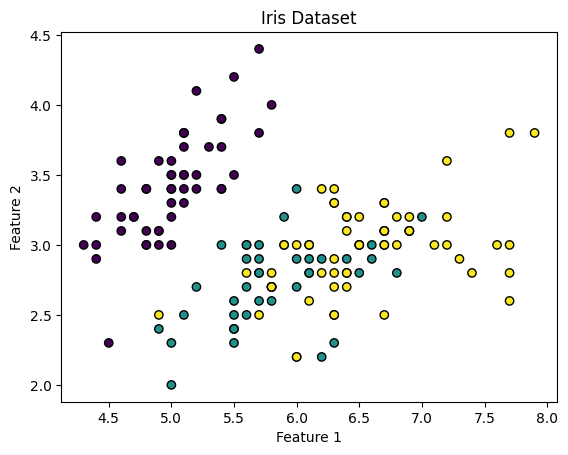

In [232]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder


# Load the Iris dataset
iris = load_iris()
X = iris.data[:, :2]  # Use only the first two features for visualization
Y = iris.target       # Target labels (0, 1, 2 for the three classes)

# One-hot encode the labels
encoder = OneHotEncoder(sparse_output=False)  # Updated argument
Y1 = encoder.fit_transform(Y.reshape(-1, 1))

# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="viridis", edgecolor="k")
plt.title("Iris Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Split into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y1, test_size=0.2, random_state=42)

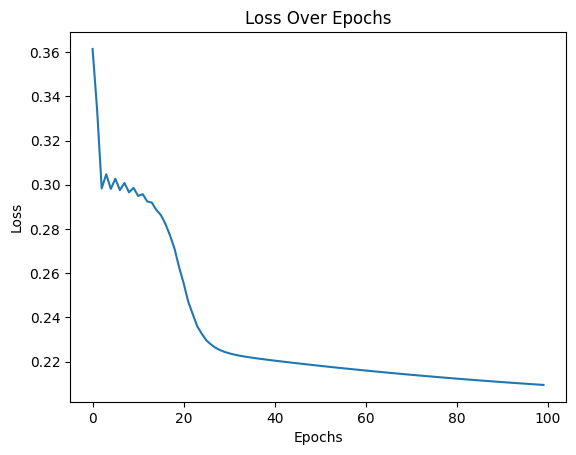

In [233]:
np.random.seed(0)
X = np.random.rand(60, 2)
Y = np.random.randint(0, 3, 60)
Y1 = np.zeros((60, 3))
Y1[np.arange(60), Y] = 1

NN = NeuralNetwork()

errors = []
epochs = 100

for epoch in range(epochs):
    output = NN.feedforward(X)
    loss = np.mean(np.square(Y1 - output))
    errors.append(loss)
    NN.train(X, Y1)

plt.plot(errors)
plt.title("Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()


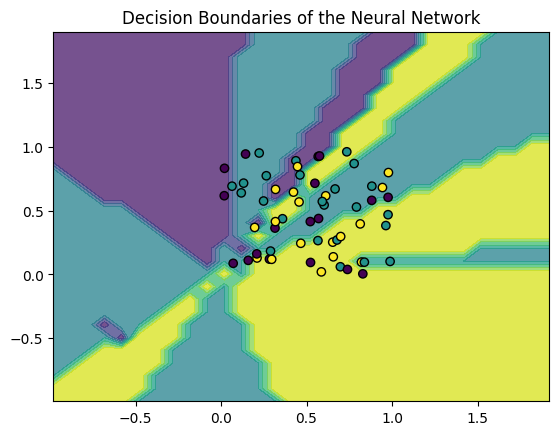

In [234]:

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = NN.feedforward(np.c_[xx.ravel(), yy.ravel()])
Z = np.argmax(Z, axis=1)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.75, cmap="viridis")
plt.scatter(X[:, 0], X[:, 1], c=Y, cmap="viridis", edgecolor="k")
plt.title("Decision Boundaries of the Neural Network")
plt.show()